In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


## Load Cleaned Dataset

In [2]:
df = pd.read_csv(
    "../data/raw/df_clean_one.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains
0,2025-07-03 04:00:00+00:00,6.63,6.74,6.61,6.64,"4,209,664.00",peloton,PTON,fitness,usa,0.00,0.00,NaN
1,2025-07-03 04:00:00+00:00,106.75,108.37,106.33,107.34,"560,190.00",crocs,CROX,footwear,usa,0.00,0.00,NaN
2,2025-07-03 04:00:00+00:00,122.63,123.05,121.55,121.93,"36,600.00",adidas,ADDYY,apparel,germany,0.00,0.00,NaN
3,2025-07-03 04:00:00+00:00,221.71,224.01,221.36,223.41,"29,295,154.00",amazon,AMZN,e-commerce,usa,0.00,0.00,NaN
4,2025-07-03 04:00:00+00:00,212.15,214.65,211.81,213.55,"34,697,317.00",apple,AAPL,technology,usa,0.00,0.00,NaN


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 310,122
Columns: 13


- The data had 310122 rows and 13 columns 

In [5]:
## Numerical Summary Statistics

numerical_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Dividends",
    "Stock Splits",
    "Capital Gains"
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,"310,122.00",76.33,141.68,0.00,15.93,35.41,84.00,"3,445.58"
High,"310,122.00",77.20,143.22,0.00,16.16,35.81,84.91,"3,463.07"
Low,"310,122.00",75.43,140.06,0.00,15.71,34.98,83.09,"3,370.00"
Close,"310,122.00",76.34,141.68,0.20,15.94,35.41,84.00,"3,427.61"
Volume,"310,122.00","22,709,366.04","85,657,437.80",0.00,"1,379,050.00","4,591,641.50","12,128,600.00","7,421,640,800.00"
Dividends,"310,122.00",0.00,0.07,0.00,0.00,0.00,0.00,15.00
Stock Splits,"310,122.00",0.00,0.12,0.00,0.00,0.00,0.00,50.00
Capital Gains,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Extended Summary Statistics

In [6]:
summary_stats = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Std Dev": df[numerical_cols].std(),
    "Skewness": df[numerical_cols].skew(),
    "Kurtosis": df[numerical_cols].kurt()
})

summary_stats

,Mean,Median,Std Dev,Skewness,Kurtosis
Open,76.33,35.41,141.68,8.23,110.33
High,77.20,35.81,143.22,8.21,109.46
Low,75.43,34.98,140.06,8.25,110.70
Close,76.34,35.41,141.68,8.22,109.99
Volume,"22,709,366.04","4,591,641.50","85,657,437.80",13.11,367.72
Dividends,0.00,0.00,0.07,74.16,"10,788.22"
Stock Splits,0.00,0.00,0.12,307.58,"120,186.73"
Capital Gains,0.00,0.00,0.00,NaN,NaN


## Distribution of Numerical Variables

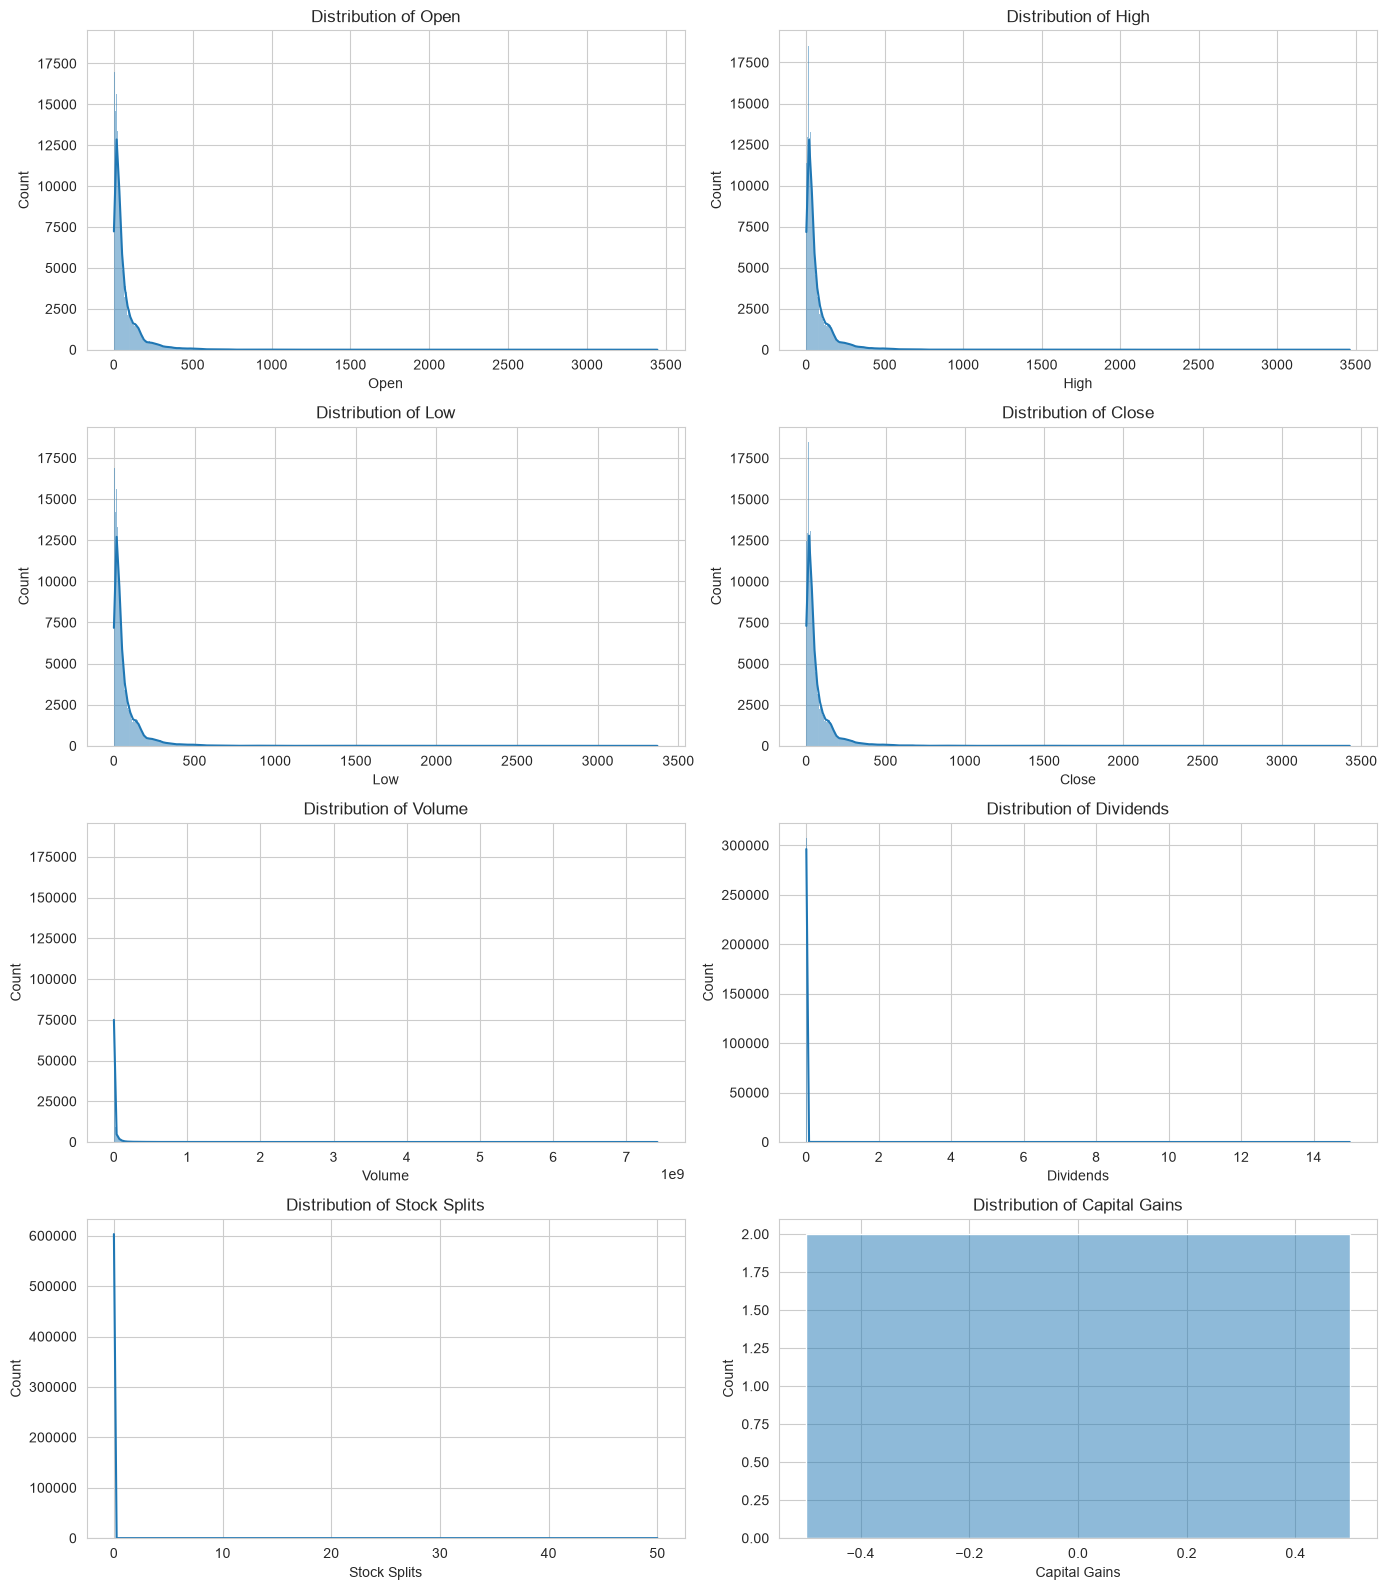

In [23]:
import math

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

# Remove any empty subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Boxplots

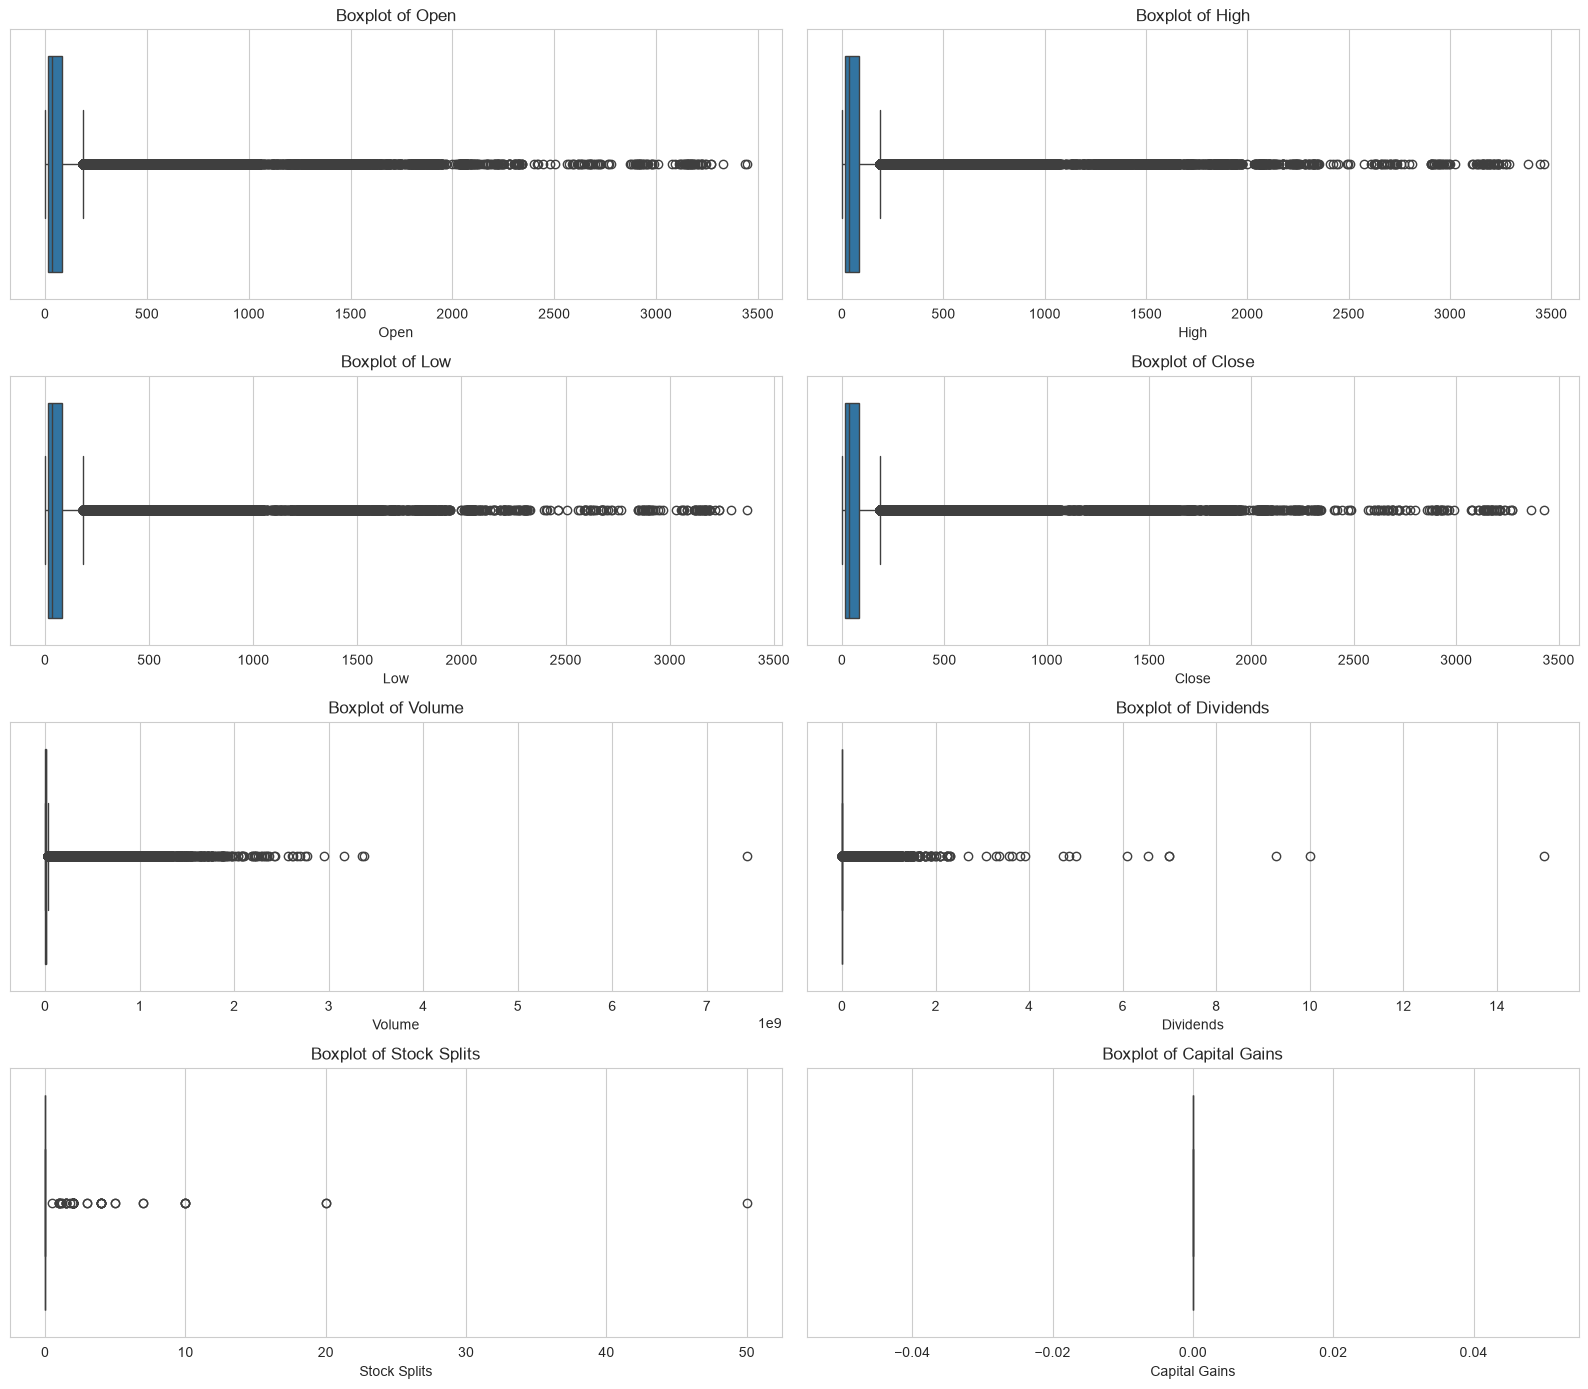

In [24]:
n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3.5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

# Remove empty subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
# Industry Frequency

industry_counts = (
    df["Industry_Tag"]
    .value_counts()
    .head(15)
)

industry_counts

Industry_Tag
technology         66957
retail             25842
automotive         24867
finance            22210
apparel            21069
food & beverage    19409
consumer goods     19407
entertainment      12342
gaming             11546
food               11415
footwear           11407
aviation           11098
hospitality        10633
e-commerce          9072
healthcare          6470
Name: count, dtype: int64

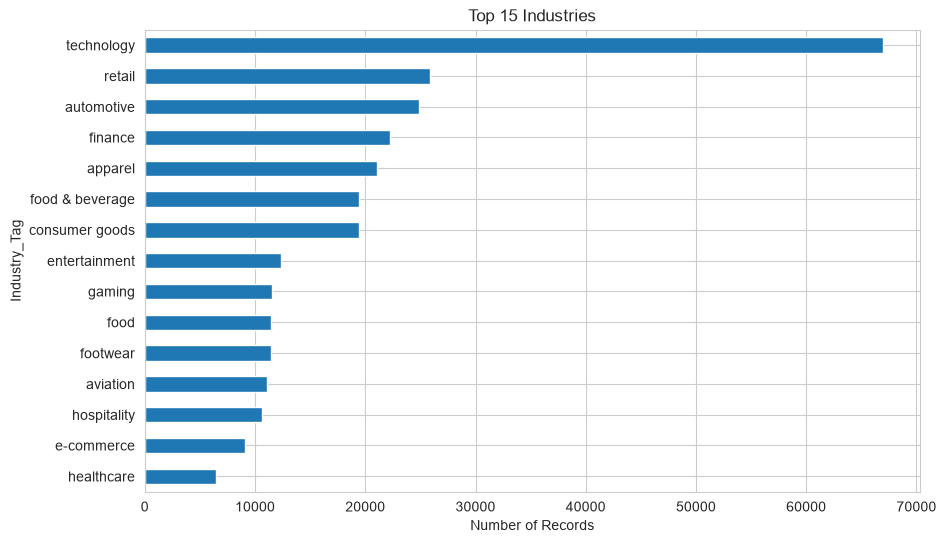

In [10]:
plt.figure(figsize=(10,6))

industry_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Industries")
plt.xlabel("Number of Records")

plt.show()

In [11]:
# Country Analysis

country_counts = (
    df["Country"]
    .value_counts()
)

country_counts

Country
usa            243606
japan           19403
germany         16225
netherlands     12938
france           8879
switzerland      6469
canada           2602
Name: count, dtype: int64

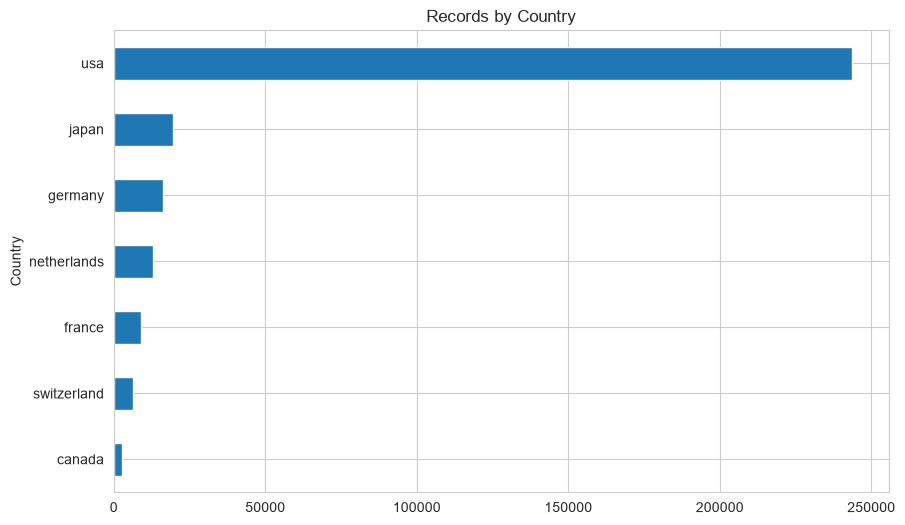

In [12]:
plt.figure(figsize=(10,6))

country_counts.sort_values().plot(
    kind="barh"
)

plt.title("Records by Country")

plt.show()

In [13]:
# Top Brands

brand_counts = (
    df["Brand_Name"]
    .value_counts()
    .head(20)
)

brand_counts

Brand_Name
marriott                     6471
amazon                       6470
apple                        6470
nike                         6470
target                       6470
the walt disney company      6470
costco                       6470
southwest airlines           6470
american eagle outfitters    6470
starbucks                    6470
nvidia                       6470
amd                          6470
american express             6470
mcdonald's                   6470
adobe                        6470
cisco                        6470
jpmorgan chase & co          6470
johnson & johnson            6470
3m                           6470
foot locker                  6470
Name: count, dtype: int64

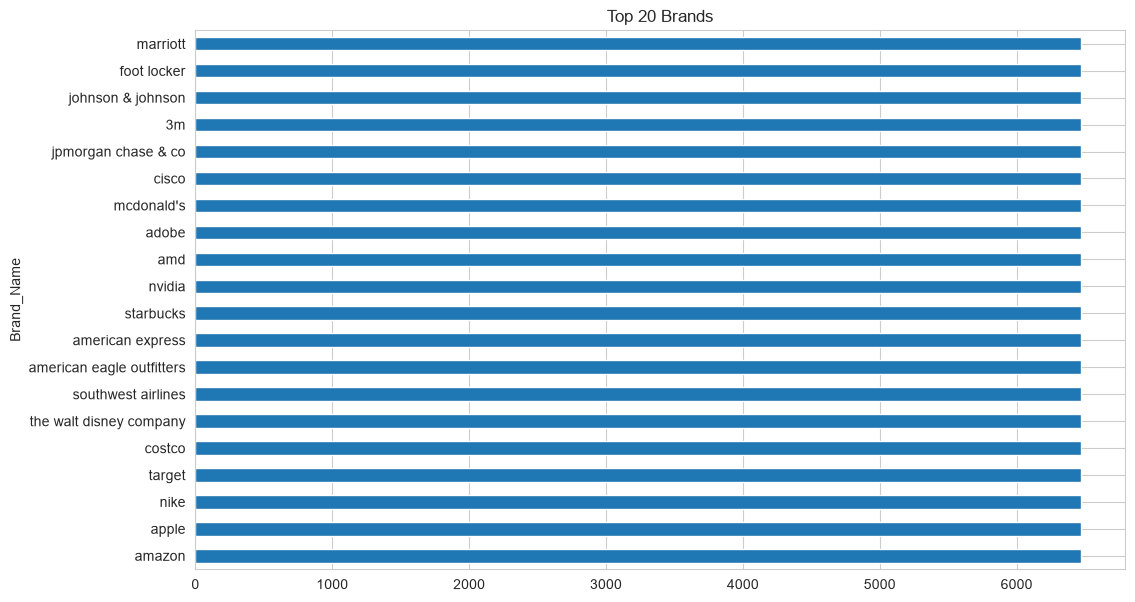

In [14]:
plt.figure(figsize=(12,7))

brand_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Brands")

plt.show()

In [15]:
# Correlation Analysis

corr_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

In [16]:
corr_matrix = df[corr_cols].corr()

corr_matrix

,Open,High,Low,Close,Volume
Open,1.00,1.00,1.00,1.00,-0.07
High,1.00,1.00,1.00,1.00,-0.07
Low,1.00,1.00,1.00,1.00,-0.07
Close,1.00,1.00,1.00,1.00,-0.07
Volume,-0.07,-0.07,-0.07,-0.07,1.00


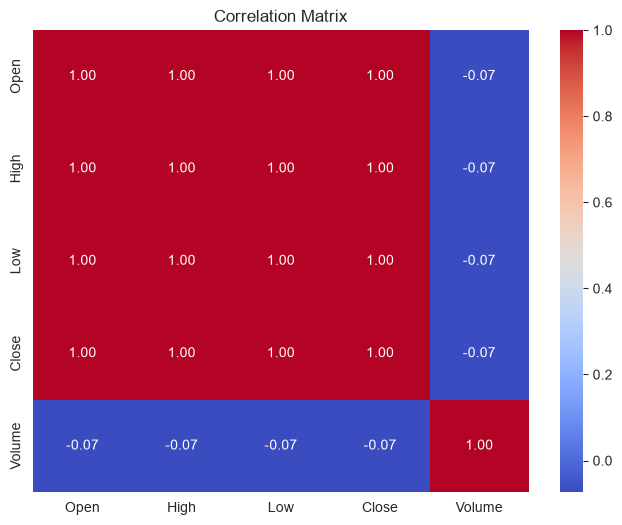

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

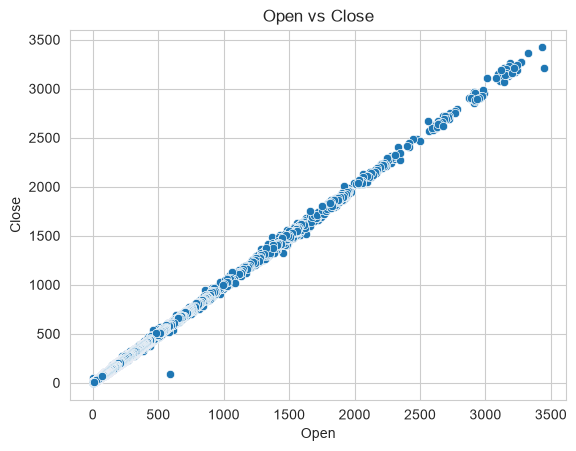

In [18]:
# Scatterplots

sns.scatterplot(
    data=df,
    x="Open",
    y="Close"
)

plt.title("Open vs Close")

plt.show()

In [19]:
# Industry vs Closing Price

top_industries = (
    df["Industry_Tag"]
    .value_counts()
    .head(10)
    .index
)

industry_df = df[
    df["Industry_Tag"].isin(top_industries)
]

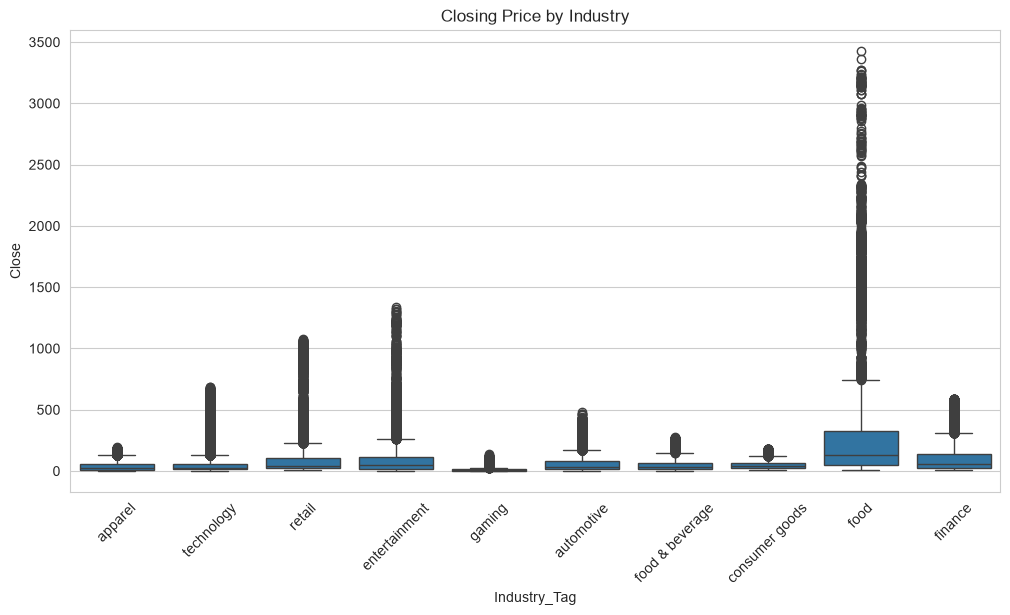

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=industry_df,
    x="Industry_Tag",
    y="Close"
)

plt.xticks(rotation=45)

plt.title(
    "Closing Price by Industry"
)

plt.show()

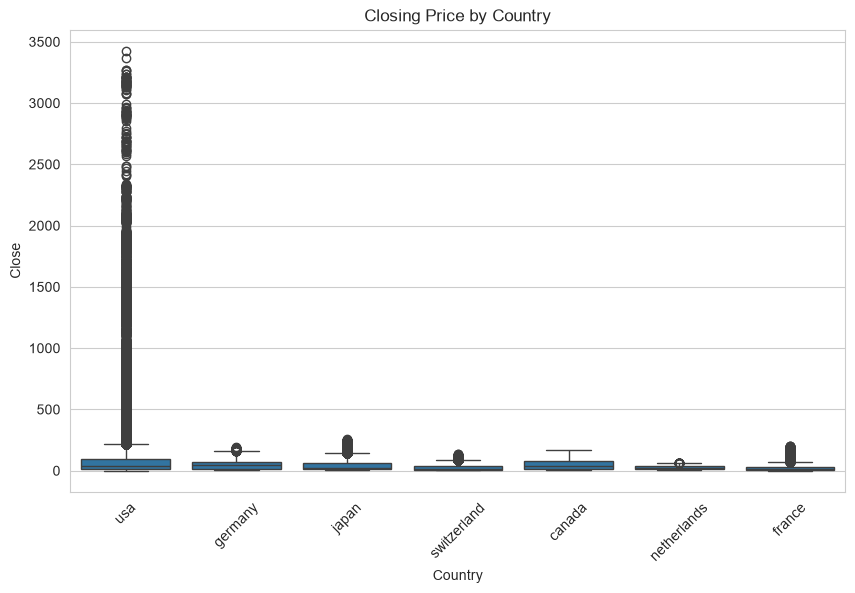

In [ ]:
# Country vs Closing Price

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Country",
    y="Close"
)

plt.xticks(rotation=45)

plt.title(
    "Closing Price by Country"
)

plt.show()